**Step 1: Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Step 2: Import Required Libraries**

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

**Step 3: Define Paths for the Forehead Dataset**

Here i will process only the Forhead folder for DownSyndrome and Healthy.

In [ ]:
#Defining source and destination paths for Forehead part
source_dir = '/content/drive/My Drive/Face_Fea_Extract'
destination_dir = '/content/drive/My Drive/FaceClassificationData/Forehead'


classes = {"DownSyndrome": "1", "Healthy": "0"}

#Creating Train and Val directories/folders for Forehead
for split in ['Train', 'Val']:
    for class_label in classes.values():
        os.makedirs(os.path.join(destination_dir, split, class_label), exist_ok=True)

print("Directory structure for Forehead created successfully!")

Directory structure for Forehead created successfully!


**Step 4: Dataset Splitting for Forehead**

This step will split the Forehead dataset into Train and Val for both classes.

In [ ]:
#Splitting and organize Forehead data
for class_name, label in classes.items():
    #The Path to the Forehead folder for each class
    class_path = os.path.join(source_dir, class_name, 'Forehead')
    all_images = []

    # Collecting all images from Forehead folder
    for file in os.listdir(class_path):
        if file.endswith(('.jpg', '.png')):
            all_images.append(os.path.join(class_path, file))

    #Splitting into Train and Val
    train_images, val_images = train_test_split(all_images, train_size=0.8, random_state=42)

    #Copying files to Train and Val directories
    for img in train_images:
        shutil.copy(img, os.path.join(destination_dir, 'Train', label))
    for img in val_images:
        shutil.copy(img, os.path.join(destination_dir, 'Val', label))

print("Forehead dataset split and organized successfully!")

Forehead dataset split and organized successfully!


**Step 5: Verify Folder Contents**

In [ ]:
#Verifying Train folder for Healthy
!ls '/content/drive/My Drive/FaceClassificationData/Forehead/Train/0'

#Verifying Train folder for DownSyndrome
!ls '/content/drive/My Drive/FaceClassificationData/Forehead/Train/1'

forehead_healty_1000.jpg  forehead_healty_1442.jpg  forehead_healty_564.jpg
forehead_healty_1001.jpg  forehead_healty_1443.jpg  forehead_healty_565.jpg
forehead_healty_1003.jpg  forehead_healty_1445.jpg  forehead_healty_566.jpg
forehead_healty_1004.jpg  forehead_healty_1446.jpg  forehead_healty_568.jpg
forehead_healty_1005.jpg  forehead_healty_1447.jpg  forehead_healty_569.jpg
forehead_healty_1006.jpg  forehead_healty_1449.jpg  forehead_healty_56.jpg
forehead_healty_1007.jpg  forehead_healty_144.jpg   forehead_healty_570.jpg
forehead_healty_1009.jpg  forehead_healty_1450.jpg  forehead_healty_571.jpg
forehead_healty_100.jpg   forehead_healty_1451.jpg  forehead_healty_573.jpg
forehead_healty_1010.jpg  forehead_healty_1452.jpg  forehead_healty_574.jpg
forehead_healty_1011.jpg  forehead_healty_1453.jpg  forehead_healty_575.jpg
forehead_healty_1012.jpg  forehead_healty_1456.jpg  forehead_healty_576.jpg
forehead_healty_1013.jpg  forehead_healty_1457.jpg  forehead_healty_577.jpg
forehead_heal

**Step 6: Visualize Sample Images**

Healthy Forehead - Train:


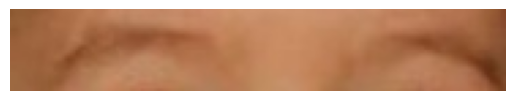

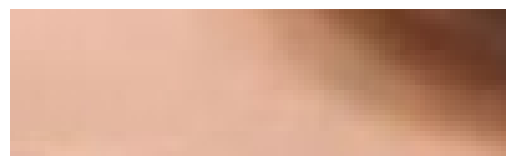

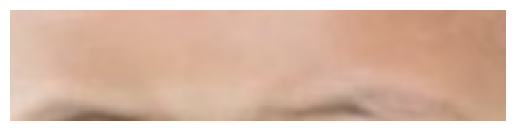

Down Syndrome Forehead - Train:


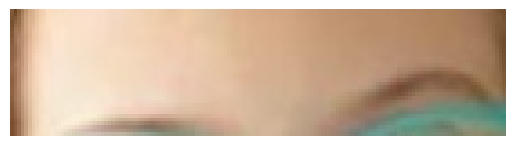

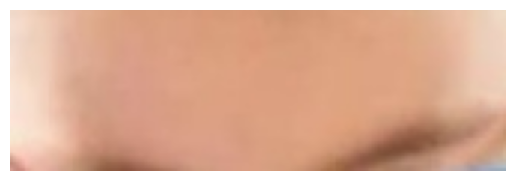

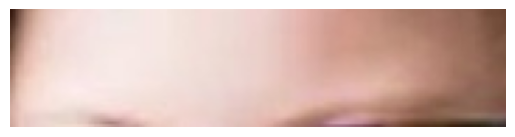

In [ ]:
#Function to display sample images
def display_samples(path, num_samples=3):
    images = [os.path.join(path, img) for img in os.listdir(path)[:num_samples]]
    for img_path in images:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.axis('off')
        plt.show()

#Displaying samples for Healthy Forehead
print("Healthy Forehead - Train:")
display_samples('/content/drive/My Drive/FaceClassificationData/Forehead/Train/0')

#Displaying samples for DownSyndrome Forehead
print("Down Syndrome Forehead - Train:")
display_samples('/content/drive/My Drive/FaceClassificationData/Forehead/Train/1')

**Step 7: Install YOLO Framework**

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 896.3/896.3 kB 18.0 MB/s eta 0:00:00


**Step 8: Train YOLO Model**

In [ ]:
from ultralytics import YOLO

#Loading YOLO model
model = YOLO("yolo11n-cls.pt")  #checkpoint

#Training the model using the corrected Forehead dataset
results = model.train(
    data='/content/drive/My Drive/FaceClassificationData/Forehead',  #Dataset path
    epochs=20,                  # Number of epochs
    imgsz=224,                  # Image size
    batch=16,                   # Batch size
    project="FaceClassificationResults/Forehead"  #Saving results in my specified folder
)

print("Training completed successfully!")

Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=classify, mode=train, model=yolo11n-cls.pt, data=/content/drive/My Drive/FaceClassificationData/Forehead, epochs=20, time=None, patience=100, batch=16, imgsz=224, save=True, save_period=-1, cache=False, device=None, workers=8, project=FaceClassificationResults/Forehead, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False

train: Scanning /content/drive/My Drive/FaceClassificationData/Forehead/train... 2374 images, 0 corrupt: 100%|██████████| 2374/2374 [00:38<00:00, 60.95it/s] 


train: New cache created: /content/drive/My Drive/FaceClassificationData/Forehead/train.cache


val: Scanning /content/drive/My Drive/FaceClassificationData/Forehead/val... 594 images, 0 corrupt: 100%|██████████| 594/594 [00:07<00:00, 82.06it/s] 


val: New cache created: /content/drive/My Drive/FaceClassificationData/Forehead/val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 39 weight(decay=0.0), 40 weight(decay=0.0005), 40 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 224 train, 224 val
Using 0 dataloader workers
Logging results to FaceClassificationResults/Forehead/train2
Starting training for 20 epochs...

      Epoch    GPU_mem       loss  Instances       Size


...

      20/20         0G      0.468          6        224: 100%|██████████| 149/149 [02:58<00:00,  1.20s/it]
               classes   top1_acc   top5_acc: 100%|██████████| 19/19 [00:19<00:00,  1.00s/it]

                   all      0.724          1



20 epochs completed in 1.098 hours.
Optimizer stripped from FaceClassificationResults/Forehead/train2/weights/last.pt, 3.2MB
Optimizer stripped from FaceClassificationResults/Forehead/train2/weights/best.pt, 3.2MB

Validating FaceClassificationResults/Forehead/train2/weights/best.pt...
Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLO11n-cls summary (fused): 112 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /content/drive/My Drive/FaceClassificationData/Forehead/train... found 2374 images in 2 classes ✅ 
val: /content/drive/My Drive/FaceClassificationData/Forehead/val... found 594 images in 2 classes ✅ 
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 19/19 [00:18<00:00,  1.01it/s]


                   all      0.742          1
Speed: 0.0ms preprocess, 17.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to FaceClassificationResults/Forehead/train2
Training completed successfully!


**Step 9: Validate the Model**

In [ ]:
#Validating the model using the Forehead dataset
metrics = model.val()
print("Validation Results for Forehead:", metrics)

Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLO11n-cls summary (fused): 112 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /content/drive/My Drive/FaceClassificationData/Forehead/train... found 2374 images in 2 classes ✅ 
val: /content/drive/My Drive/FaceClassificationData/Forehead/val... found 594 images in 2 classes ✅ 
test: None...


val: Scanning /content/drive/My Drive/FaceClassificationData/Forehead/val... 594 images, 0 corrupt: 100%|██████████| 594/594 [00:00<?, ?it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 38/38 [00:18<00:00,  2.05it/s]


                   all      0.742          1
Speed: 0.0ms preprocess, 15.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to FaceClassificationResults/Forehead/train22
Validation Results for Forehead: ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78a2137ad210>
curves: []
curves_results: []
fitness: 0.8712121248245239
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.7424242496490479, 'metrics/accuracy_top5': 1.0, 'fitness': 0.8712121248245239}
save_dir: PosixPath('FaceClassificationResults/Forehead/train22')
speed: {'preprocess': 0.0018828645699754708, 'inference': 15.373356013185647, 'loss': 0.0003283272688637679, 'postprocess': 0.00020470282044073547}
task: 'classify'
top1: 0.7424242496490479
top5: 1.0


**Step 10: Analyze Predictions and Compute Metrics**

Generate Predictions and Labels

In [ ]:
#Path to validation data for Forehead
val_path = '/content/drive/My Drive/FaceClassificationData/Forehead/val'

true_labels, predicted_labels = [], []

for class_label in ["0", "1"]:  # Healthy=0, Down Syndrome=1
    class_dir = os.path.join(val_path, class_label)
    for img_file in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_file)
        prediction = model(img_path, verbose=False)
        probs = prediction[0].probs
        # Use top1 attribute instead of argmax
        predicted_class = probs.top1
        true_labels.append(int(class_label))
        predicted_labels.append(predicted_class)

print("Predictions for Forehead completed!")

Predictions for Forehead completed!


Calculate and Display Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

#Calculating accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy for Forehead: {accuracy * 100:.2f}%")

Accuracy for Forehead: 74.24%


Generate Classification Report

In [ ]:
from sklearn.metrics import classification_report

#Generating classification report
report = classification_report(true_labels, predicted_labels, target_names=["Healthy", "Down Syndrome"])
print("Classification Report for Forehead:\n", report)

Classification Report for Forehead:
                precision    recall  f1-score   support

      Healthy       0.69      0.88      0.77       297
Down Syndrome       0.83      0.61      0.70       297

     accuracy                           0.74       594
    macro avg       0.76      0.74      0.74       594
 weighted avg       0.76      0.74      0.74       594



Generate Confusion Matrix

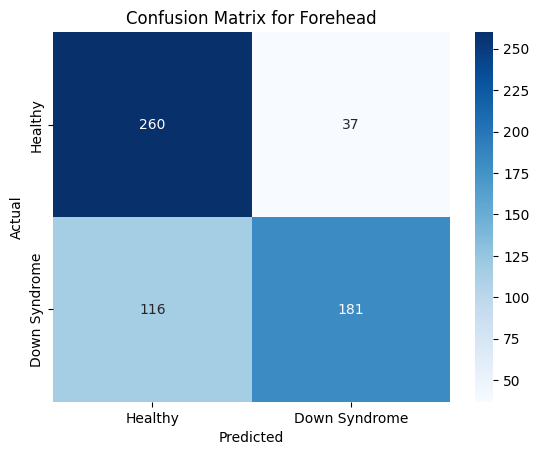

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Generating confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

#Visualizing confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Healthy", "Down Syndrome"], yticklabels=["Healthy", "Down Syndrome"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Forehead')
plt.show()

**Step 11: ROC Curve and AUC**

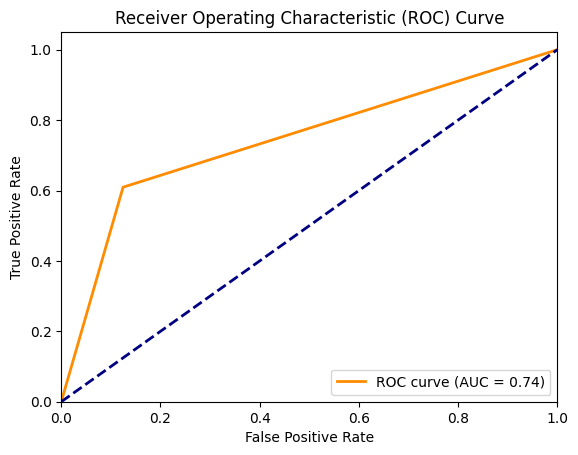

In [ ]:
from sklearn.metrics import roc_curve, auc

#Computing ROC curve and AUC
fpr, tpr, thresholds = roc_curve(true_labels, predicted_labels, pos_label=1)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()